# 第四章：机械手臂逆运动学 — 交互式可视化升级版

> 台大林沛群教授《机器人学》第四章  
> 这一版沿用 Chapter03 的思路：Notebook 负责推导与局部互动，独立网页负责更强的演示体验。

| Part | 内容 |
|------|------|
| 1 | 2R 解析 IK：两组分支与几何量 |
| 2 | 工作空间圆环与水平切片的分支连续性 |
| 3 | 奇异点、`det(J)` 与速度椭圆 |
| 4 | Pick-and-Place：按连续性选择 IK 分支 |
| 5 | Pieper / wrist center 示意 + Three.js IK Studio |
| 6 | 批量导出静态图 |


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches
from matplotlib import font_manager as fm
from pathlib import Path
import textwrap
import warnings
from ipywidgets import FloatSlider, Dropdown, ToggleButtons, interactive_output, VBox, HBox
from IPython.display import display, HTML as IPHTML

warnings.filterwarnings("ignore")
%matplotlib inline


def _pick_font():
    want = [
        "Microsoft YaHei",
        "Microsoft YaHei UI",
        "SimHei",
        "NSimSun",
        "Microsoft JhengHei",
        "Noto Sans CJK SC",
        "DejaVu Sans",
    ]
    installed = {f.name for f in fm.fontManager.ttflist}
    for name in want:
        if name in installed:
            return name
    return "DejaVu Sans"


CJK = _pick_font()
plt.rcParams.update(
    {
        "font.family": CJK,
        "font.sans-serif": [CJK, "DejaVu Sans"],
        "axes.unicode_minus": False,
        "figure.dpi": 110,
    }
)

L1, L2 = 1.2, 0.9
INNER_RADIUS = abs(L1 - L2)
OUTER_RADIUS = L1 + L2
VIEW_RADIUS = OUTER_RADIUS + 0.25

BRANCH_COLORS = {
    "elbow-up": "#2563eb",
    "elbow-down": "#16a34a",
}


def wrap_deg(angle):
    return (angle + 180.0) % 360.0 - 180.0


def fk_planar(theta1_deg, theta2_deg, l1=L1, l2=L2):
    t1 = np.radians(theta1_deg)
    t12 = np.radians(theta1_deg + theta2_deg)
    p0 = np.array([0.0, 0.0])
    p1 = np.array([l1 * np.cos(t1), l1 * np.sin(t1)])
    p2 = p1 + np.array([l2 * np.cos(t12), l2 * np.sin(t12)])
    return np.vstack([p0, p1, p2])


def ik_terms(x, y, l1=L1, l2=L2):
    r2 = x ** 2 + y ** 2
    r = np.sqrt(r2)
    c2 = (r2 - l1 ** 2 - l2 ** 2) / (2 * l1 * l2)
    beta = np.degrees(np.arctan2(y, x))
    return {"r": r, "r2": r2, "c2": c2, "beta": beta}


def jacobian(theta1_deg, theta2_deg, l1=L1, l2=L2):
    t1 = np.radians(theta1_deg)
    t12 = np.radians(theta1_deg + theta2_deg)
    return np.array(
        [
            [-l1 * np.sin(t1) - l2 * np.sin(t12), -l2 * np.sin(t12)],
            [l1 * np.cos(t1) + l2 * np.cos(t12), l2 * np.cos(t12)],
        ]
    )


def jacobian_det(theta2_deg, l1=L1, l2=L2):
    return l1 * l2 * np.sin(np.radians(theta2_deg))


def manipulability(theta2_deg, l1=L1, l2=L2):
    return abs(jacobian_det(theta2_deg, l1, l2))


def workspace_state(x, y, l1=L1, l2=L2):
    r = np.hypot(x, y)
    inner = abs(l1 - l2)
    outer = l1 + l2
    eps = 1e-9
    if r < inner - eps:
        return "too-close"
    if r > outer + eps:
        return "too-far"
    if abs(r - inner) <= 2e-3 or abs(r - outer) <= 2e-3:
        return "boundary"
    return "reachable"


def ik_2r(x, y, l1=L1, l2=L2):
    terms = ik_terms(x, y, l1, l2)
    c2 = terms["c2"]
    if c2 < -1.0 or c2 > 1.0:
        return []

    c2 = np.clip(c2, -1.0, 1.0)
    s2_abs = np.sqrt(max(0.0, 1.0 - c2 ** 2))
    solutions = []

    for branch, s2 in [("elbow-up", s2_abs), ("elbow-down", -s2_abs)]:
        theta2 = np.degrees(np.arctan2(s2, c2))
        k1 = l1 + l2 * c2
        k2 = l2 * s2
        gamma = np.degrees(np.arctan2(k2, k1))
        theta1 = np.degrees(np.arctan2(y, x) - np.arctan2(k2, k1))
        pts = fk_planar(theta1, theta2, l1, l2)
        elbow = pts[1]
        solutions.append(
            {
                "branch": branch,
                "theta1": wrap_deg(theta1),
                "theta2": wrap_deg(theta2),
                "gamma": gamma,
                "beta": terms["beta"],
                "elbow": elbow,
                "pts": pts,
                "detJ": jacobian_det(theta2, l1, l2),
                "manip": manipulability(theta2, l1, l2),
            }
        )

    solutions.sort(key=lambda item: item["theta2"], reverse=True)
    return solutions


def angle_distance(cfg_a, cfg_b):
    da = wrap_deg(cfg_a[0] - cfg_b[0])
    db = wrap_deg(cfg_a[1] - cfg_b[1])
    return float(np.hypot(da, db))


def draw_workspace(ax, title="2R 工作空间", show_labels=True):
    annulus = patches.Wedge(
        (0, 0),
        OUTER_RADIUS,
        0,
        360,
        width=OUTER_RADIUS - INNER_RADIUS,
        facecolor="#dbeafe",
        alpha=0.28,
        edgecolor="none",
    )
    ax.add_patch(annulus)
    ax.add_patch(
        patches.Circle((0, 0), OUTER_RADIUS, fill=False, lw=2, ls="--", ec="#1d4ed8", alpha=0.85)
    )
    ax.add_patch(
        patches.Circle((0, 0), INNER_RADIUS, fill=False, lw=2, ls="--", ec="#7c3aed", alpha=0.75)
    )
    ax.scatter(0, 0, s=90, color="#111827", zorder=6)
    if show_labels:
        ax.text(0.06, OUTER_RADIUS + 0.03, f"outer = {OUTER_RADIUS:.2f}", color="#1d4ed8", fontsize=9)
        ax.text(0.06, INNER_RADIUS + 0.03, f"inner = {INNER_RADIUS:.2f}", color="#7c3aed", fontsize=9)
    ax.set_aspect("equal")
    ax.set_xlim(-VIEW_RADIUS, VIEW_RADIUS)
    ax.set_ylim(-VIEW_RADIUS, VIEW_RADIUS)
    ax.grid(True, alpha=0.22)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(title, fontsize=11, fontweight="bold")


def draw_arm(ax, pts, color="#2563eb", label=None, alpha=1.0, lw=3.5):
    ax.plot(pts[:, 0], pts[:, 1], "-o", color=color, lw=lw, ms=7, alpha=alpha, label=label)
    ax.scatter(pts[-1, 0], pts[-1, 1], s=120, color="#ef4444", edgecolor="white", linewidth=1.2, zorder=7)


def annotate_target(ax, x, y, status, label="target"):
    status_color = {
        "reachable": "#16a34a",
        "boundary": "#f59e0b",
        "too-close": "#dc2626",
        "too-far": "#dc2626",
    }[status]
    ax.scatter(x, y, s=120, color=status_color, marker="x", linewidths=2.2, zorder=8)
    ax.text(x + 0.05, y + 0.05, label, color=status_color, fontsize=9, weight="bold")


def figure_to_single_display(fig):
    plt.tight_layout()
    display(fig)
    plt.close(fig)


print(f"Chapter04 可视化工具加载完成 | 字体: {CJK}")


Chapter04 可视化工具加载完成 | 字体: Microsoft YaHei


---
## Part 1：2R 解析 IK 的两组分支

对 2R 平面机械手臂，逆运动学最重要的直觉不是“把公式背下来”，而是：

1. 先看目标点到原点的距离 `r`
2. 用余弦定理决定 `theta2`
3. `theta2` 的正负号对应两条几何分支：`elbow-up` / `elbow-down`

下面把目标点、两组 IK 解和几何量放在同一个视图里。


In [9]:
_ik_x = FloatSlider(value=1.25, min=-2.0, max=2.0, step=0.05, description="target x")
_ik_y = FloatSlider(value=0.75, min=-2.0, max=2.0, step=0.05, description="target y")


def build_two_branch_figure(target_x, target_y):
    status = workspace_state(target_x, target_y)
    sols = ik_2r(target_x, target_y)
    terms = ik_terms(target_x, target_y)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14.5, 5.2))
    draw_workspace(ax1, title="Target Point and Two IK Branches")
    annotate_target(ax1, target_x, target_y, status)
    ax1.plot([0, target_x], [0, target_y], "k--", alpha=0.35, lw=1.5)
    ax1.text(target_x * 0.52, target_y * 0.52, f"r = {terms['r']:.3f}", fontsize=9, color="#111827")

    if sols:
        for sol in sols:
            color = BRANCH_COLORS[sol["branch"]]
            draw_arm(
                ax1,
                sol["pts"],
                color=color,
                label=f"{sol['branch']} | theta1={sol['theta1']:.1f} deg, theta2={sol['theta2']:.1f} deg",
                alpha=0.92,
            )
            ax1.plot(
                [sol["pts"][1, 0], target_x],
                [sol["pts"][1, 1], target_y],
                color=color,
                lw=1.3,
                alpha=0.55,
            )
        ax1.legend(loc="lower left", fontsize=8, frameon=True)
    else:
        ax1.text(
            -2.0,
            -2.12,
            "This target lies outside the annulus workspace, so no analytical IK solution exists.",
            color="#b91c1c",
            fontsize=9,
        )

    ax2.axis("off")
    lines = [
        "Geometry Summary",
        f"target = ({target_x:.2f}, {target_y:.2f})",
        f"r = sqrt(x^2 + y^2) = {terms['r']:.4f}",
        f"cos(theta2) = {terms['c2']:.4f}",
        f"beta = atan2(y, x) = {terms['beta']:.2f} deg",
        "",
        "Workspace Check",
        f"|l1-l2| = {INNER_RADIUS:.2f},   l1+l2 = {OUTER_RADIUS:.2f}",
        f"status = {status}",
        "",
        "Formula Recap",
        "theta2 = +/- arccos((x^2+y^2-l1^2-l2^2)/(2 l1 l2))",
        "theta1 = beta - atan2(l2 sin(theta2), l1 + l2 cos(theta2))",
        "",
    ]

    if sols:
        for sol in sols:
            lines.extend(
                [
                    sol["branch"],
                    f"  theta1 = {sol['theta1']:.3f} deg",
                    f"  theta2 = {sol['theta2']:.3f} deg",
                    f"  gamma  = {sol['gamma']:.3f} deg",
                    f"  det(J) = {sol['detJ']:.4f}",
                    "",
                ]
            )
    else:
        lines.extend(
            [
                "No-Solution Notes",
                "  If r > l1 + l2: the target is too far away.",
                "  If r < |l1 - l2|: the target is too close to be reached.",
            ]
        )

    ax2.text(
        0.0,
        1.0,
        "\n".join(lines),
        va="top",
        ha="left",
        fontsize=10,
        family="monospace",
        color="#0f172a",
    )
    return fig


def show_two_branch_figure(target_x, target_y):
    plt.close("all")
    figure_to_single_display(build_two_branch_figure(target_x, target_y))


_out_ik = interactive_output(show_two_branch_figure, {"target_x": _ik_x, "target_y": _ik_y})
display(VBox([HBox([_ik_x, _ik_y]), _out_ik]))


---
## Part 2：工作空间圆环与分支连续性

第四章真正想建立的是“解空间”的直觉：

- 目标点在 annulus 外，IK 直接无解
- 目标点落到边界时，两条分支会并成一条
- 沿着一条连续任务路径移动时，`theta1 / theta2` 其实是在各自的分支曲线上滑动

下面左图看几何位置，右边两张图看固定 `y` 切片下的关节角曲线。


In [10]:
_slice_x = FloatSlider(value=1.40, min=-2.0, max=2.0, step=0.05, description="probe x")
_slice_y = FloatSlider(value=0.50, min=-2.0, max=2.0, step=0.05, description="slice y")


def branch_slice_curves(slice_y, num=321):
    xs = np.linspace(-OUTER_RADIUS, OUTER_RADIUS, num)
    curves = {
        "elbow-up": {"x": [], "theta1": [], "theta2": []},
        "elbow-down": {"x": [], "theta1": [], "theta2": []},
    }
    for x in xs:
        for sol in ik_2r(x, slice_y):
            curves[sol["branch"]]["x"].append(x)
            curves[sol["branch"]]["theta1"].append(sol["theta1"])
            curves[sol["branch"]]["theta2"].append(sol["theta2"])
    return curves


def build_workspace_slice_figure(probe_x, slice_y):
    curves = branch_slice_curves(slice_y)
    state = workspace_state(probe_x, slice_y)
    current = ik_2r(probe_x, slice_y)

    fig = plt.figure(figsize=(15.5, 5.2))
    gs = fig.add_gridspec(1, 3, width_ratios=[1.15, 1.0, 1.0])
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])

    draw_workspace(ax1, title="annulus 工作空间 + 水平切片")
    ax1.axhline(slice_y, color="#64748b", lw=1.8, ls="--", alpha=0.75)
    annotate_target(ax1, probe_x, slice_y, state, label=f"probe @ y={slice_y:.2f}")

    for branch, color in BRANCH_COLORS.items():
        if branch in [sol["branch"] for sol in current]:
            pts = next(sol["pts"] for sol in current if sol["branch"] == branch)
            draw_arm(ax1, pts, color=color, alpha=0.75, lw=2.8)

    for branch, color in BRANCH_COLORS.items():
        ax2.plot(curves[branch]["x"], curves[branch]["theta1"], color=color, lw=2.1, label=branch)
        ax3.plot(curves[branch]["x"], curves[branch]["theta2"], color=color, lw=2.1, label=branch)

    for ax, title, ylabel in [
        (ax2, "固定 y 时的 theta1 分支", "theta1 (deg)"),
        (ax3, "固定 y 时的 theta2 分支", "theta2 (deg)"),
    ]:
        ax.axvline(probe_x, color="#ef4444", lw=1.3, ls="--", alpha=0.85)
        ax.grid(True, alpha=0.24)
        ax.set_xlabel("x along slice")
        ax.set_ylabel(ylabel)
        ax.set_title(title, fontsize=10.5, fontweight="bold")

    if current:
        for sol in current:
            ax2.scatter([probe_x], [sol["theta1"]], color=BRANCH_COLORS[sol["branch"]], s=55, zorder=5)
            ax3.scatter([probe_x], [sol["theta2"]], color=BRANCH_COLORS[sol["branch"]], s=55, zorder=5)
    else:
        ax2.text(0.03, 0.95, "该切片位置无解", transform=ax2.transAxes, va="top", color="#b91c1c")
        ax3.text(0.03, 0.95, "两条分支在这里都不存在", transform=ax3.transAxes, va="top", color="#b91c1c")

    ax2.legend(loc="lower left", fontsize=8, frameon=True)
    return fig


def show_workspace_slice_figure(probe_x, slice_y):
    plt.close("all")
    figure_to_single_display(build_workspace_slice_figure(probe_x, slice_y))


_out_slice = interactive_output(show_workspace_slice_figure, {"probe_x": _slice_x, "slice_y": _slice_y})
display(VBox([HBox([_slice_x, _slice_y]), _out_slice]))


---
## Part 3：奇异点、`det(J)` 与速度椭圆

课程里说“奇异点会退化”，最容易误解成一句抽象判断。  
更直观的看法是：

- 关节速度空间本来是一个单位圆
- 经过雅可比矩阵 `J` 映射到末端速度空间后，会变成一个速度椭圆
- 当 `det(J) -> 0` 时，这个椭圆会被压扁，说明某个任务方向几乎失去可控性


In [11]:
_sg_t1 = FloatSlider(value=25, min=-180, max=180, step=5, description="theta1")
_sg_t2 = FloatSlider(value=25, min=-180, max=180, step=5, description="theta2")


def build_singularity_figure(theta1, theta2):
    pts = fk_planar(theta1, theta2)
    ee = pts[-1]
    J = jacobian(theta1, theta2)
    detj = float(np.linalg.det(J))
    singular = abs(detj) < 1e-3

    phis = np.linspace(0, 2 * np.pi, 240)
    qdot_unit = np.vstack([np.cos(phis), np.sin(phis)])
    vel = (J @ qdot_unit).T
    max_norm = max(np.linalg.norm(vel, axis=1).max(), 1e-6)
    scale = 0.48 / max_norm
    ellipse = ee + vel * scale

    fig, axes = plt.subplots(1, 3, figsize=(16.2, 5.1))
    ax1, ax2, ax3 = axes

    draw_workspace(ax1, title="当前姿态与奇异位置")
    draw_arm(ax1, pts, color="#f59e0b", lw=3.8)
    annotate_target(ax1, ee[0], ee[1], "boundary" if singular else "reachable", label="EE")

    ax2.set_aspect("equal")
    ax2.grid(True, alpha=0.25)
    ax2.plot(ellipse[:, 0], ellipse[:, 1], color="#7c3aed", lw=2.5, label="J · unit circle")
    ax2.scatter(ee[0], ee[1], s=100, color="#111827", zorder=6)
    ax2.arrow(ee[0], ee[1], *(J[:, 0] * scale), width=0.01, color="#2563eb", alpha=0.85, label="qdot1")
    ax2.arrow(ee[0], ee[1], *(J[:, 1] * scale), width=0.01, color="#16a34a", alpha=0.85, label="qdot2")
    ax2.set_xlim(ee[0] - 0.9, ee[0] + 0.9)
    ax2.set_ylim(ee[1] - 0.9, ee[1] + 0.9)
    ax2.set_title("末端速度椭圆", fontsize=11, fontweight="bold")
    ax2.set_xlabel("vx direction")
    ax2.set_ylabel("vy direction")
    ax2.legend(loc="upper right", fontsize=8, frameon=True)

    theta2_grid = np.linspace(-180, 180, 500)
    det_grid = jacobian_det(theta2_grid)
    ax3.plot(theta2_grid, det_grid, color="#9333ea", lw=2.4)
    ax3.axhline(0, color="#64748b", ls="--", lw=1.2)
    ax3.axvline(theta2, color="#ef4444", ls="--", lw=1.4)
    ax3.scatter([theta2], [detj], s=70, color="#ef4444", zorder=6)
    ax3.set_title("det(J) = l1 l2 sin(theta2)", fontsize=11, fontweight="bold")
    ax3.set_xlabel("theta2 (deg)")
    ax3.set_ylabel("det(J)")
    ax3.grid(True, alpha=0.24)

    txt = [
        f"theta1 = {theta1:.1f}°",
        f"theta2 = {theta2:.1f}°",
        f"det(J) = {detj:.5f}",
        f"manipulability = {abs(detj):.5f}",
        "状态 = singular" if singular else "状态 = non-singular",
    ]
    ax3.text(
        0.03,
        0.96,
        "\n".join(txt),
        transform=ax3.transAxes,
        va="top",
        ha="left",
        fontsize=9.5,
        family="monospace",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8, edgecolor="#d1d5db"),
    )

    return fig


def show_singularity_figure(theta1, theta2):
    plt.close("all")
    figure_to_single_display(build_singularity_figure(theta1, theta2))


_out_sg = interactive_output(show_singularity_figure, {"theta1": _sg_t1, "theta2": _sg_t2})
display(VBox([HBox([_sg_t1, _sg_t2]), _out_sg]))


---
## Part 4：Pick-and-Place 不只是“求一组解”

真正做任务时，IK 更像在多组候选解里做选择。  
下面这个简化版策略会同时考虑：

- waypoint 是否都可达
- 从一个 waypoint 到下一个 waypoint 的关节跳变量
- 是否太靠近奇异点

因此 `auto` 模式并不是盲选 `elbow-up` 或 `elbow-down`，而是更偏向“连续、稳定”的那一支。


In [ ]:
_pick_x = FloatSlider(value=1.00, min=-1.8, max=1.8, step=0.05, description="pick x")
_pick_y = FloatSlider(value=0.35, min=-1.8, max=1.8, step=0.05, description="pick y")
_place_x = FloatSlider(value=0.15, min=-1.8, max=1.8, step=0.05, description="place x")
_place_y = FloatSlider(value=1.20, min=-1.8, max=1.8, step=0.05, description="place y")
_lift = FloatSlider(value=0.35, min=0.10, max=0.60, step=0.05, description="lift")
_policy = ToggleButtons(
    options=[("auto", "auto"), ("elbow-up", "elbow-up"), ("elbow-down", "elbow-down")],
    value="auto",
    description="policy",
)


def plan_pick_and_place(pick_xy, place_xy, lift=0.35):
    waypoints = np.array(
        [
            [pick_xy[0], pick_xy[1] + lift],
            [pick_xy[0], pick_xy[1]],
            [place_xy[0], place_xy[1] + lift],
            [place_xy[0], place_xy[1]],
        ],
        dtype=float,
    )
    labels = ["pre-pick", "pick", "pre-place", "place"]
    candidates = []

    for branch in ["elbow-up", "elbow-down"]:
        configs = []
        feasible = True
        margin = np.inf
        for pt in waypoints:
            sols = [sol for sol in ik_2r(pt[0], pt[1]) if sol["branch"] == branch]
            if not sols:
                feasible = False
                break
            cfg = sols[0]
            configs.append(cfg)
            margin = min(margin, abs(cfg["detJ"]))

        if not feasible:
            candidates.append(
                {
                    "branch": branch,
                    "feasible": False,
                    "cost": np.inf,
                    "configs": [],
                    "margin": 0.0,
                }
            )
            continue

        motion_cost = 0.0
        for prev, nxt in zip(configs[:-1], configs[1:]):
            motion_cost += angle_distance(
                (prev["theta1"], prev["theta2"]),
                (nxt["theta1"], nxt["theta2"]),
            )
        singular_penalty = 18.0 / (margin + 0.12)
        total_cost = motion_cost + singular_penalty
        candidates.append(
            {
                "branch": branch,
                "feasible": True,
                "cost": total_cost,
                "motion_cost": motion_cost,
                "singular_penalty": singular_penalty,
                "configs": configs,
                "margin": margin,
            }
        )

    feasible = [item for item in candidates if item["feasible"]]
    best = min(feasible, key=lambda item: item["cost"]) if feasible else None
    return {"waypoints": waypoints, "labels": labels, "candidates": candidates, "best": best}


def build_pick_place_figure(pick_x, pick_y, place_x, place_y, lift, policy):
    result = plan_pick_and_place((pick_x, pick_y), (place_x, place_y), lift)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14.6, 5.2))

    draw_workspace(ax1, title="Pick-and-Place waypoints")
    pts = result["waypoints"]
    ax1.plot(pts[:, 0], pts[:, 1], "--", color="#475569", lw=2.0, alpha=0.8)
    ax1.scatter(pts[:, 0], pts[:, 1], s=65, color="#111827", zorder=6)
    for pt, label in zip(pts, result["labels"]):
        ax1.text(pt[0] + 0.04, pt[1] + 0.04, label, fontsize=8.8, color="#0f172a")

    chosen = result["best"] if policy == "auto" else next(
        (item for item in result["candidates"] if item["branch"] == policy and item["feasible"]),
        None,
    )

    if chosen is not None:
        pick_cfg = chosen["configs"][1]
        place_cfg = chosen["configs"][-1]
        draw_arm(ax1, pick_cfg["pts"], color=BRANCH_COLORS[chosen["branch"]], alpha=0.85, lw=3.2)
        draw_arm(ax1, place_cfg["pts"], color="#f59e0b", alpha=0.75, lw=3.2)
        ax1.text(
            -2.05,
            -2.1,
            f"selected branch = {chosen['branch']} | total cost = {chosen['cost']:.2f}",
            fontsize=9.5,
            color="#111827",
        )
    else:
        ax1.text(
            -2.05,
            -2.1,
            "所选 branch 不可行，或四个 waypoint 里至少有一点超出工作空间。",
            fontsize=9.2,
            color="#b91c1c",
        )

    labels = [item["branch"] for item in result["candidates"]]
    values = [0.0 if not item["feasible"] else item["cost"] for item in result["candidates"]]
    colors = [BRANCH_COLORS[item["branch"]] for item in result["candidates"]]
    bars = ax2.bar(labels, values, color=colors, alpha=0.84)
    ax2.set_title("分支代价比较", fontsize=11, fontweight="bold")
    ax2.set_ylabel("cost")
    ax2.grid(True, axis="y", alpha=0.24)

    for bar, item in zip(bars, result["candidates"]):
        if item["feasible"]:
            txt = f"{item['cost']:.1f}\nΔq={item['motion_cost']:.1f}"
        else:
            txt = "unreachable"
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            max(bar.get_height(), 0.02) + 0.03,
            txt,
            ha="center",
            va="bottom",
            fontsize=9,
            color="#0f172a",
        )

    ax2.text(
        0.03,
        0.97,
        "评分逻辑\n"
        "1. 先过滤不可达分支\n"
        "2. 再累加相邻 waypoint 的关节跳变量\n"
        "3. 最后用 det(J) margin 加一点奇异惩罚",
        transform=ax2.transAxes,
        va="top",
        ha="left",
        fontsize=9.4,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#d1d5db", alpha=0.86),
    )

    return fig


def show_pick_place_figure(pick_x, pick_y, place_x, place_y, lift, policy):
    plt.close("all")
    figure_to_single_display(build_pick_place_figure(pick_x, pick_y, place_x, place_y, lift, policy))


_out_pick = interactive_output(
    show_pick_place_figure,
    {
        "pick_x": _pick_x,
        "pick_y": _pick_y,
        "place_x": _place_x,
        "place_y": _place_y,
        "lift": _lift,
        "policy": _policy,
    },
)

display(
    VBox(
        [
            HBox([_pick_x, _pick_y]),
            HBox([_place_x, _place_y]),
            HBox([_lift, _policy]),
            _out_pick,
        ]
    )
)


---
## Part 5：Pieper / Wrist Center 与独立 IK Studio

第四章的后半段并不只是在 2R 上打转。  
对 6-DoF 机械手臂，林教授强调的关键思想是：

- 若末三轴交于一点，就有 **spherical wrist**
- 先由末端姿态倒推出 **wrist center**
- 前三轴解位置，后三轴解姿态

下面先给一个 2D 示意图，然后像第三章一样，生成一个独立网页 `ik_studio.html` 作为更完整的演示入口。


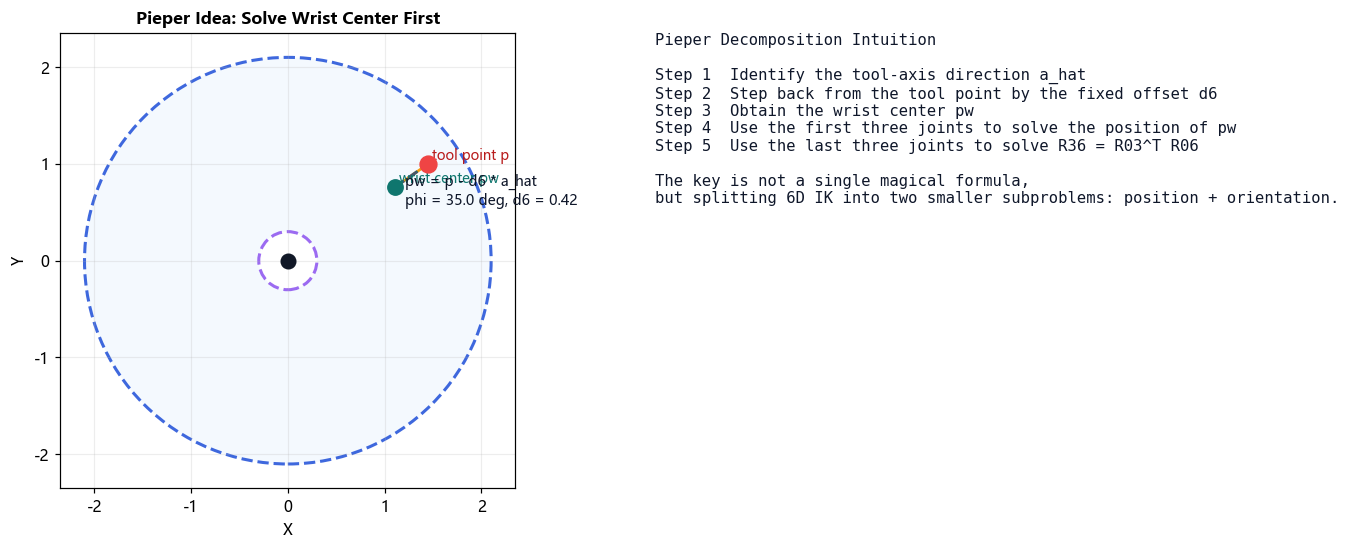

File location: d:\Code\Learning\EI\EI-learning-notes\Robotics_NTU\ik_studio.html


In [13]:
def build_wrist_center_figure(tool_xy=(1.45, 1.00), phi_deg=35.0, wrist_offset=0.42):
    tool_xy = np.array(tool_xy, dtype=float)
    a_hat = np.array([np.cos(np.radians(phi_deg)), np.sin(np.radians(phi_deg))])
    wrist_xy = tool_xy - wrist_offset * a_hat

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14.2, 5.1))
    draw_workspace(ax1, title="Pieper Idea: Solve Wrist Center First", show_labels=False)
    ax1.scatter(*tool_xy, s=120, color="#ef4444", zorder=6)
    ax1.scatter(*wrist_xy, s=100, color="#0f766e", zorder=6)
    ax1.plot([wrist_xy[0], tool_xy[0]], [wrist_xy[1], tool_xy[1]], "--", color="#475569", lw=2.0)
    ax1.arrow(
        wrist_xy[0],
        wrist_xy[1],
        *(a_hat * wrist_offset),
        width=0.012,
        color="#f59e0b",
        length_includes_head=True,
    )
    ax1.text(tool_xy[0] + 0.04, tool_xy[1] + 0.04, "tool point p", color="#b91c1c", fontsize=9)
    ax1.text(wrist_xy[0] + 0.04, wrist_xy[1] + 0.04, "wrist center pw", color="#0f766e", fontsize=9)
    ax1.text(
        wrist_xy[0] + 0.10,
        wrist_xy[1] - 0.18,
        f"pw = p - d6 * a_hat\nphi = {phi_deg:.1f} deg, d6 = {wrist_offset:.2f}",
        fontsize=9.3,
        color="#0f172a",
    )

    ax2.axis("off")
    ax2.text(
        0.0,
        1.0,
        "\n".join(
            [
                "Pieper Decomposition Intuition",
                "",
                "Step 1  Identify the tool-axis direction a_hat",
                "Step 2  Step back from the tool point by the fixed offset d6",
                "Step 3  Obtain the wrist center pw",
                "Step 4  Use the first three joints to solve the position of pw",
                "Step 5  Use the last three joints to solve R36 = R03^T R06",
                "",
                "The key is not a single magical formula,",
                "but splitting 6D IK into two smaller subproblems: position + orientation.",
            ]
        ),
        va="top",
        ha="left",
        fontsize=10.2,
        family="monospace",
        color="#0f172a",
    )
    return fig


figure_to_single_display(build_wrist_center_figure())


def _resolve_notebook_dir():
    cwd = Path.cwd()
    for base in (cwd, cwd / "Robotics_NTU", cwd / "EI-learning-notes" / "Robotics_NTU"):
        if (base / "Chapter04_visualization.ipynb").exists():
            return base
    return cwd


IK_HTML = textwrap.dedent(r"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>IK Studio</title>
<style>
:root{--bg:#07111a;--bg2:#0c1823;--panel:rgba(8,18,28,.88);--line:rgba(124,228,255,.16);--text:#ecf8ff;--muted:#8eacbe;--acc:#7ce4ff;--warn:#ffb867;--bad:#ff7b7b}
*{box-sizing:border-box}html,body{height:100%;margin:0}
body{overflow:hidden;color:var(--text);font-family:"Bahnschrift","Segoe UI Variable","Segoe UI",sans-serif;background:radial-gradient(circle at 15% 15%,rgba(124,228,255,.13),transparent 24%),radial-gradient(circle at 82% 12%,rgba(255,184,103,.10),transparent 18%),linear-gradient(160deg,#02080d 0%,var(--bg) 36%,var(--bg2) 100%)}
.app{display:grid;grid-template-columns:360px 1fr;height:100%}
.panel{display:flex;flex-direction:column;gap:14px;padding:16px;min-height:0;background:linear-gradient(180deg,rgba(8,18,28,.95),rgba(7,16,25,.74));border-right:1px solid var(--line);backdrop-filter:blur(20px);z-index:2}
.scroll{flex:1;min-height:0;overflow:auto;padding-right:6px;padding-bottom:28px}
.scroll::-webkit-scrollbar{width:10px}.scroll::-webkit-scrollbar-thumb{background:rgba(124,228,255,.14);border-radius:999px}
.hero,.sec,.hud,.credit{border:1px solid var(--line);background:var(--panel);backdrop-filter:blur(18px)}
.hero{padding:16px;border-radius:22px;background:radial-gradient(circle at top right,rgba(124,228,255,.16),transparent 26%),linear-gradient(180deg,rgba(14,30,45,.92),rgba(9,19,30,.88))}
.eyebrow{display:inline-flex;padding:6px 10px;border-radius:999px;border:1px solid rgba(124,228,255,.18);background:rgba(124,228,255,.08);color:var(--acc);font-size:11px;letter-spacing:.12em;text-transform:uppercase}
.hero h1{margin:12px 0 8px;font-size:30px;letter-spacing:-.04em}
.hero p{margin:0;color:#b3c9d8;font-size:13px;line-height:1.6}
.meta{display:grid;grid-template-columns:repeat(3,1fr);gap:8px;margin-top:14px}
.meta div{padding:10px 12px;border-radius:16px;background:rgba(124,228,255,.06);border:1px solid rgba(124,228,255,.12)}
.meta b{display:block;font-size:14px}.meta span{font-size:10px;color:var(--muted);letter-spacing:.12em;text-transform:uppercase}
.sec{padding:14px;border-radius:20px}
.sec h2{margin:0 0 12px;font-size:12px;letter-spacing:.14em;text-transform:uppercase;color:var(--muted)}
.grid2,.grid3,.stats{display:grid;gap:10px}.grid2{grid-template-columns:repeat(2,1fr)}.grid3{grid-template-columns:repeat(3,1fr)}.stats{grid-template-columns:repeat(2,1fr)}
button,input{font:inherit}
.btn,.mode,.preset{border:1px solid rgba(124,228,255,.16);background:rgba(124,228,255,.04);color:var(--text);border-radius:16px;transition:.18s;cursor:pointer}
.btn:hover,.mode:hover,.preset:hover{transform:translateY(-1px);border-color:rgba(124,228,255,.42)}
.mode.active,.preset.active,.btn.active{background:linear-gradient(180deg,rgba(124,228,255,.22),rgba(124,228,255,.10));border-color:rgba(124,228,255,.6);box-shadow:0 0 0 1px rgba(124,228,255,.2) inset,0 8px 24px rgba(124,228,255,.12)}
.mode,.preset,.btn{padding:11px 12px;font-size:12px;font-weight:600}
.mode small,.preset small{display:block;color:var(--muted);font-size:11px;line-height:1.45;margin-top:3px}
.sliders{display:grid;gap:12px}
.row{padding:12px;border-radius:18px;background:rgba(124,228,255,.04);border:1px solid rgba(124,228,255,.10)}
.head{display:flex;justify-content:space-between;gap:10px;margin-bottom:8px}
.name{font-size:14px;font-weight:600}.val{color:var(--acc);font:12px Consolas,monospace}
input[type=range]{width:100%;height:28px;margin:0;accent-color:var(--acc);background:transparent}
.stat{padding:12px;border-radius:16px;background:rgba(124,228,255,.05);border:1px solid rgba(124,228,255,.10)}.stat span{display:block}
.lab{color:var(--muted);font-size:10px;letter-spacing:.12em;text-transform:uppercase;margin-bottom:4px}.num{font:15px Consolas,monospace}
.note{margin-top:10px;color:var(--muted);font-size:12px;line-height:1.55}
.stage{position:relative;min-width:0}#vp{position:absolute;inset:0}
.hud{position:absolute;left:18px;right:18px;top:18px;display:flex;justify-content:space-between;gap:14px;padding:12px 14px;border-radius:18px;pointer-events:none}
.hud strong{display:block;font-size:13px}.hud span{display:block;color:var(--muted);font-size:11px;margin-top:2px}
.pills{display:flex;gap:8px;flex-wrap:wrap}.pill{padding:8px 10px;border-radius:999px;border:1px solid rgba(124,228,255,.14);background:rgba(124,228,255,.08);font-size:11px;letter-spacing:.08em;text-transform:uppercase}
.credit{position:absolute;right:18px;bottom:18px;padding:10px 12px;border-radius:16px;color:var(--muted);font-size:11px;line-height:1.55}.credit b{color:#fff}
@media (max-width:1180px){.app{grid-template-columns:1fr}.panel{position:absolute;left:16px;top:16px;bottom:16px;width:min(360px,calc(100vw - 32px));border:1px solid var(--line);border-radius:26px}}
</style>
</head>
<body>
<div class="app">
  <aside class="panel">
    <section class="hero">
      <div class="eyebrow">Chapter 04 IK Studio</div>
      <h1>Branch Explorer</h1>
      <p>Built on the same standalone-viewer stack as Chapter03, this Three.js + OrbitControls scene combines the target, workspace, IK branches, and singularity cues in one GPU view.</p>
      <div class="meta"><div><span>Renderer</span><b>WebGL</b></div><div><span>Focus</span><b>IK / Singularity</b></div><div><span>Branch</span><b>Auto / Manual</b></div></div>
    </section>
    <div class="scroll">
      <section class="sec"><h2>Target</h2><div class="sliders" id="sliders"></div></section>
      <section class="sec"><h2>Branch Mode</h2><div class="grid3"><button class="mode active" data-mode="auto">Auto<small>Closest to the current joint state</small></button><button class="mode" data-mode="elbow-up">Elbow Up<small>Lock to the elbow-up branch</small></button><button class="mode" data-mode="elbow-down">Elbow Down<small>Lock to the elbow-down branch</small></button></div></section>
      <section class="sec"><h2>Presets</h2><div class="grid2"><button class="preset active" data-preset="reach">Reachable<small>A standard reachable point</small></button><button class="preset" data-preset="outer">Outer Boundary<small>Near theta2 = 0</small></button><button class="preset" data-preset="inner">Inner Boundary<small>Near theta2 = 180</small></button><button class="preset" data-preset="left">Left Reach<small>Move across the workspace to inspect continuity</small></button></div></section>
      <section class="sec"><h2>Display</h2><div class="grid2"><button class="btn active" id="tg-axes">Axes<small>Show the end-effector local frame</small></button><button class="btn active" id="tg-target">Target Stem<small>Highlight the target and its projection</small></button></div></section>
      <section class="sec"><h2>Status</h2><div class="stats"><div class="stat"><span class="lab">x</span><span class="num" id="xv">0.0000</span></div><div class="stat"><span class="lab">y</span><span class="num" id="yv">0.0000</span></div><div class="stat"><span class="lab">theta1</span><span class="num" id="t1v">0.0 deg</span></div><div class="stat"><span class="lab">theta2</span><span class="num" id="t2v">0.0 deg</span></div><div class="stat"><span class="lab">detJ</span><span class="num" id="djv">0.0000</span></div><div class="stat"><span class="lab">branch</span><span class="num" id="brv">auto</span></div><div class="stat"><span class="lab">reach</span><span class="num" id="rv">reachable</span></div><div class="stat"><span class="lab">status</span><span class="num" id="sv">ok</span></div></div><div class="note" id="note">Auto mode prefers the branch closest to the current joint state, making branch continuity easier to observe while dragging the target.</div></section>
    </div>
  </aside>
  <main class="stage">
    <div id="vp"></div>
    <div class="hud"><div><strong>2R Analytical IK</strong><span>The annulus workspace, end-effector marker, two links, and local frame update together in one view.</span></div><div class="pills"><div class="pill">Two Branches</div><div class="pill">Singularity Aware</div><div class="pill">Standalone Viewer</div></div></div>
    <div class="credit"><b>Tip</b><br>Left drag to orbit, right drag to pan, and scroll to zoom.<br>Drag the target and watch the two IK branches merge near the workspace boundary.</div>
  </main>
</div>

<script type="importmap">{"imports":{"three":"https://cdn.jsdelivr.net/npm/three@0.160.0/build/three.module.js","three/addons/":"https://cdn.jsdelivr.net/npm/three@0.160.0/examples/jsm/"}}</script>
<script type="module">
import * as T from 'three';
import {OrbitControls} from 'three/addons/controls/OrbitControls.js';

const L1 = 1.2, L2 = 0.9, INNER = Math.abs(L1 - L2), OUTER = L1 + L2;
const $ = (id) => document.getElementById(id);

const ui = {
  sliders: $('sliders'),
  xv: $('xv'), yv: $('yv'), t1v: $('t1v'), t2v: $('t2v'),
  djv: $('djv'), brv: $('brv'), rv: $('rv'), sv: $('sv'), note: $('note'),
  targetBtn: $('tg-target'), axesBtn: $('tg-axes'),
  modes: [...document.querySelectorAll('.mode')],
  presets: [...document.querySelectorAll('.preset')]
};

const vp = $('vp');
const ren = new T.WebGLRenderer({antialias: true, powerPreference: 'high-performance'});
ren.setPixelRatio(Math.min(devicePixelRatio, 2));
ren.outputColorSpace = T.SRGBColorSpace;
ren.shadowMap.enabled = true;
ren.shadowMap.type = T.VSMShadowMap;
ren.toneMapping = T.ACESFilmicToneMapping;
ren.toneMappingExposure = 1.05;
vp.appendChild(ren.domElement);

const scene = new T.Scene();
scene.background = new T.Color(0x050c13);
scene.fog = new T.FogExp2(0x071019, 0.045);
const cam = new T.PerspectiveCamera(42, 1, 0.02, 90);
cam.position.set(3.5, 2.6, 3.5);
const ctrl = new OrbitControls(cam, ren.domElement);
ctrl.enableDamping = true;
ctrl.dampingFactor = 0.06;
ctrl.minDistance = 1.0;
ctrl.maxDistance = 18;
ctrl.target.set(0, 0.32, 0);

function resize(){
  const w = vp.clientWidth, h = vp.clientHeight;
  ren.setSize(w, h);
  cam.aspect = w / h;
  cam.updateProjectionMatrix();
}
addEventListener('resize', resize); resize();

scene.add(new T.HemisphereLight(0xa8dbff, 0x081018, 1.1));
const key = new T.DirectionalLight(0xffffff, 3.2);
key.position.set(4.2, 6.4, 2.6);
key.castShadow = true;
key.shadow.mapSize.set(2048, 2048);
Object.assign(key.shadow.camera, {left: -6, right: 6, top: 6, bottom: -6, near: 0.3, far: 22});
scene.add(key);
const rim = new T.DirectionalLight(0x89b7ff, 0.9); rim.position.set(-5.2, 2.5, -3.4); scene.add(rim);
const fill = new T.PointLight(0xffcf92, 0.8, 18, 2); fill.position.set(0, 3.0, 0); scene.add(fill);

const floor = new T.Mesh(
  new T.CircleGeometry(7.0, 120),
  new T.MeshPhysicalMaterial({color: 0x0a1823, roughness: 0.86, metalness: 0.08, clearcoat: 0.24, clearcoatRoughness: 0.38})
);
floor.rotation.x = -Math.PI / 2;
floor.receiveShadow = true;
scene.add(floor);
const grid = new T.GridHelper(10, 40, 0x2d6b84, 0x143243);
grid.material.transparent = true;
grid.material.opacity = 0.32;
scene.add(grid);

function ringPoints(r, y=0.002, n=180){
  const pts = [];
  for(let i=0;i<n;i++){
    const t = i / n * Math.PI * 2;
    pts.push(new T.Vector3(r * Math.cos(t), y, -r * Math.sin(t)));
  }
  return pts;
}
scene.add(new T.LineLoop(new T.BufferGeometry().setFromPoints(ringPoints(OUTER)), new T.LineBasicMaterial({color:0x7ce4ff, transparent:true, opacity:0.52})));
scene.add(new T.LineLoop(new T.BufferGeometry().setFromPoints(ringPoints(INNER)), new T.LineBasicMaterial({color:0xc084fc, transparent:true, opacity:0.48})));

const mats = {
  base: new T.MeshPhysicalMaterial({color: 0x102334, roughness: 0.36, metalness: 0.78, clearcoat: 0.42}),
  joint: new T.MeshPhysicalMaterial({color: 0xeaf7ff, roughness: 0.18, metalness: 1, clearcoat: 0.72}),
  link1: new T.MeshPhysicalMaterial({color: 0x27b7ff, roughness: 0.28, metalness: 0.64, clearcoat: 0.34}),
  link2: new T.MeshPhysicalMaterial({color: 0x64da7d, roughness: 0.28, metalness: 0.64, clearcoat: 0.34}),
  ee: new T.MeshPhysicalMaterial({color: 0xffc56f, emissive: 0x6f2b00, emissiveIntensity: 1.1, roughness: 0.16, metalness: 0.96}),
  bad: new T.MeshPhysicalMaterial({color: 0xff7b7b, emissive: 0x5f1414, emissiveIntensity: 0.7, roughness: 0.22, metalness: 0.84})
};
const root = new T.Group(); scene.add(root);
const targetRoot = new T.Group(); scene.add(targetRoot);
const arm = {};

function mkLink(mat){
  const g = new T.Group();
  const body = new T.Mesh(new T.CylinderGeometry(1, 1, 1, 28, 1, true), mat);
  const a = new T.Mesh(new T.SphereGeometry(1, 26, 26), mat);
  const b = new T.Mesh(new T.SphereGeometry(1, 26, 26), mat);
  [body, a, b].forEach((m) => { m.castShadow = true; m.receiveShadow = true; g.add(m); });
  g.userData = {body, a, b};
  return g;
}
function setLink(link, p1, p2, r){
  const dir = new T.Vector3().subVectors(p2, p1), L = dir.length();
  if(L < 1e-4){ link.visible = false; return; }
  link.visible = true;
  link.position.copy(p1).add(p2).multiplyScalar(0.5);
  link.quaternion.setFromUnitVectors(new T.Vector3(0, 1, 0), dir.clone().normalize());
  const h = Math.max(L - 2 * r, 0.001), u = link.userData;
  u.body.scale.set(r, h, r);
  u.a.scale.set(r, r, r);
  u.b.scale.set(r, r, r);
  u.a.position.set(0, h * 0.5, 0);
  u.b.position.set(0, -h * 0.5, 0);
}
function mapP(x, y, lift=0.12){ return new T.Vector3(x, lift, -y); }
function wrapDeg(a){ return (a + 180) % 360 - 180; }
function angularDistance(a, b){
  const d1 = wrapDeg(a[0] - b[0]), d2 = wrapDeg(a[1] - b[1]);
  return Math.hypot(d1, d2);
}
function fk(theta1, theta2){
  const t1 = theta1 * Math.PI / 180;
  const t12 = (theta1 + theta2) * Math.PI / 180;
  const p0 = [0, 0];
  const p1 = [L1 * Math.cos(t1), L1 * Math.sin(t1)];
  const p2 = [p1[0] + L2 * Math.cos(t12), p1[1] + L2 * Math.sin(t12)];
  return [p0, p1, p2];
}
function ik(x, y){
  const r2 = x * x + y * y;
  let c2 = (r2 - L1 * L1 - L2 * L2) / (2 * L1 * L2);
  if(c2 < -1 || c2 > 1) return [];
  c2 = Math.max(-1, Math.min(1, c2));
  const s2abs = Math.sqrt(Math.max(0, 1 - c2 * c2));
  const out = [];
  [['elbow-up', s2abs], ['elbow-down', -s2abs]].forEach(([branch, s2]) => {
    const theta2 = Math.atan2(s2, c2) * 180 / Math.PI;
    const k1 = L1 + L2 * c2, k2 = L2 * s2;
    const theta1 = (Math.atan2(y, x) - Math.atan2(k2, k1)) * 180 / Math.PI;
    out.push({branch, theta1: wrapDeg(theta1), theta2: wrapDeg(theta2), detJ: L1 * L2 * Math.sin(theta2 * Math.PI / 180)});
  });
  out.sort((a, b) => b.theta2 - a.theta2);
  return out;
}
function workspaceState(x, y){
  const r = Math.hypot(x, y);
  if(r < INNER - 1e-9) return 'too-close';
  if(r > OUTER + 1e-9) return 'too-far';
  if(Math.abs(r - INNER) < 0.015 || Math.abs(r - OUTER) < 0.015) return 'boundary';
  return 'reachable';
}

function buildArm(){
  const pedestal = new T.Mesh(new T.CylinderGeometry(0.17, 0.21, 0.12, 40), mats.base);
  pedestal.position.y = 0.06;
  pedestal.castShadow = pedestal.receiveShadow = true;
  root.add(pedestal);
  const cap = new T.Mesh(new T.CylinderGeometry(0.14, 0.14, 0.035, 40), mats.joint);
  cap.position.y = 0.137;
  cap.castShadow = true;
  root.add(cap);
  arm.link1 = mkLink(mats.link1); root.add(arm.link1);
  arm.link2 = mkLink(mats.link2); root.add(arm.link2);
  arm.j0 = new T.Mesh(new T.SphereGeometry(0.095, 28, 28), mats.joint); root.add(arm.j0);
  arm.j1 = new T.Mesh(new T.SphereGeometry(0.082, 28, 28), mats.joint); root.add(arm.j1);
  arm.ee = new T.Mesh(new T.SphereGeometry(0.068, 30, 30), mats.ee); root.add(arm.ee);
  [arm.j0, arm.j1, arm.ee].forEach((m) => { m.castShadow = m.receiveShadow = true; });
  arm.axes = new T.AxesHelper(0.24); root.add(arm.axes);

  arm.targetStem = new T.Line(
    new T.BufferGeometry().setFromPoints([new T.Vector3(), new T.Vector3(0, 1, 0)]),
    new T.LineDashedMaterial({color:0xffc987, dashSize:0.08, gapSize:0.05, transparent:true, opacity:0.55})
  );
  targetRoot.add(arm.targetStem);
  arm.targetStem.computeLineDistances();
  arm.targetRing = new T.Mesh(new T.RingGeometry(0.055, 0.078, 48), new T.MeshBasicMaterial({color:0xffb867, transparent:true, opacity:0.56, side:T.DoubleSide}));
  arm.targetRing.rotation.x = -Math.PI / 2;
  targetRoot.add(arm.targetRing);
  arm.targetGlow = new T.Mesh(new T.TorusGeometry(0.078, 0.008, 12, 64), new T.MeshBasicMaterial({color:0xffb867, transparent:true, opacity:0.92}));
  arm.targetGlow.rotation.x = -Math.PI / 2;
  targetRoot.add(arm.targetGlow);
  arm.targetBall = new T.Mesh(new T.SphereGeometry(0.052, 28, 28), mats.ee.clone());
  arm.targetBall.castShadow = true;
  targetRoot.add(arm.targetBall);
}
buildArm();

const state = {
  x: 1.2,
  y: 0.75,
  mode: 'auto',
  showAxes: true,
  showTarget: true,
  current: [25, 35]
};

const SLIDER_CFG = [
  {key: 'x', label: 'target x', min: -2.0, max: 2.0, step: 0.01},
  {key: 'y', label: 'target y', min: -2.0, max: 2.0, step: 0.01}
];
function buildSliders(){
  ui.sliders.innerHTML = '';
  SLIDER_CFG.forEach((cfg) => {
    const row = document.createElement('div');
    row.className = 'row';
    row.innerHTML = `<div class="head"><span class="name">${cfg.label}</span><span class="val" id="val-${cfg.key}">${state[cfg.key].toFixed(2)}</span></div><input type="range" id="sl-${cfg.key}" min="${cfg.min}" max="${cfg.max}" step="${cfg.step}" value="${state[cfg.key]}">`;
    const input = row.querySelector('input');
    input.addEventListener('input', () => {
      state[cfg.key] = parseFloat(input.value);
      row.querySelector('.val').textContent = state[cfg.key].toFixed(2);
      update();
    });
    ui.sliders.appendChild(row);
  });
}
buildSliders();

ui.modes.forEach((btn) => btn.addEventListener('click', () => {
  ui.modes.forEach((b) => b.classList.remove('active'));
  btn.classList.add('active');
  state.mode = btn.dataset.mode;
  update();
}));
ui.presets.forEach((btn) => btn.addEventListener('click', () => {
  ui.presets.forEach((b) => b.classList.remove('active'));
  btn.classList.add('active');
  const preset = btn.dataset.preset;
  const presets = {
    reach: [1.20, 0.75],
    outer: [2.06, 0.05],
    inner: [0.32, 0.02],
    left: [-0.85, 1.05]
  };
  [state.x, state.y] = presets[preset];
  $('sl-x').value = state.x; $('sl-y').value = state.y;
  $('val-x').textContent = state.x.toFixed(2); $('val-y').textContent = state.y.toFixed(2);
  update();
}));
ui.axesBtn.addEventListener('click', () => { state.showAxes = !state.showAxes; ui.axesBtn.classList.toggle('active', state.showAxes); update(); });
ui.targetBtn.addEventListener('click', () => { state.showTarget = !state.showTarget; ui.targetBtn.classList.toggle('active', state.showTarget); update(); });

function updateTargetVisual(x, y, reachable){
  const floorP = mapP(x, y, 0.004);
  const topP = mapP(x, y, 0.12);
  arm.targetRing.position.copy(floorP);
  arm.targetGlow.position.copy(floorP).add(new T.Vector3(0, 0.002, 0));
  arm.targetBall.position.copy(topP);
  const geom = new T.BufferGeometry().setFromPoints([floorP, topP]);
  arm.targetStem.geometry.dispose();
  arm.targetStem.geometry = geom;
  arm.targetStem.computeLineDistances();
  arm.targetStem.visible = state.showTarget;
  arm.targetRing.visible = state.showTarget;
  arm.targetGlow.visible = state.showTarget;
  arm.targetBall.visible = true;
  arm.targetBall.material = reachable ? mats.ee : mats.bad;
}

function chooseSolution(solutions){
  if(!solutions.length) return null;
  if(state.mode === 'elbow-up') return solutions.find((s) => s.branch === 'elbow-up') || null;
  if(state.mode === 'elbow-down') return solutions.find((s) => s.branch === 'elbow-down') || null;
  let best = solutions[0], bestCost = Infinity;
  solutions.forEach((sol) => {
    const cost = angularDistance([sol.theta1, sol.theta2], state.current);
    if(cost < bestCost){ best = sol; bestCost = cost; }
  });
  return best;
}

function setArm(theta1, theta2, reachable){
  const [p0, p1, p2] = fk(theta1, theta2);
  const a0 = mapP(p0[0], p0[1]), a1 = mapP(p1[0], p1[1]), a2 = mapP(p2[0], p2[1]);
  setLink(arm.link1, a0, a1, 0.06);
  setLink(arm.link2, a1, a2, 0.05);
  arm.j0.position.copy(a0);
  arm.j1.position.copy(a1);
  arm.ee.position.copy(a2);
  arm.ee.material = reachable ? mats.ee : mats.bad;
  arm.axes.position.copy(a2);
  const phi = (theta1 + theta2) * Math.PI / 180;
  arm.axes.setRotationFromMatrix(new T.Matrix4().makeRotationY(0));
  arm.axes.rotation.set(0, -phi, 0);
  arm.axes.visible = state.showAxes && reachable;
}

function updateStats(solution, reachState){
  ui.xv.textContent = state.x.toFixed(4);
  ui.yv.textContent = state.y.toFixed(4);
  ui.rv.textContent = reachState;
  if(solution){
    ui.t1v.textContent = solution.theta1.toFixed(1) + ' deg';
    ui.t2v.textContent = solution.theta2.toFixed(1) + ' deg';
    ui.djv.textContent = solution.detJ.toFixed(4);
    ui.brv.textContent = state.mode === 'auto' ? 'auto -> ' + solution.branch : solution.branch;
    ui.sv.textContent = Math.abs(solution.detJ) < 1e-3 ? 'near singular' : 'ok';
    ui.note.textContent = Math.abs(solution.detJ) < 1e-3
      ? 'The current target is close to the boundary, so the velocity ellipse flattens and one end-effector direction becomes hard to control.'
      : 'Drag the target to see how Auto preserves branch continuity and how det(J) decays near the boundary.';
  }else{
    ui.t1v.textContent = 'N/A';
    ui.t2v.textContent = 'N/A';
    ui.djv.textContent = 'N/A';
    ui.brv.textContent = state.mode;
    ui.sv.textContent = 'no IK';
    ui.note.textContent = 'The current target lies outside the annulus workspace, so analytical IK has no solution here.';
  }
}

function update(){
  const reachState = workspaceState(state.x, state.y);
  const solutions = ik(state.x, state.y);
  const chosen = chooseSolution(solutions);
  updateTargetVisual(state.x, state.y, reachState !== 'too-close' && reachState !== 'too-far');
  if(chosen){
    state.current = [chosen.theta1, chosen.theta2];
    setArm(chosen.theta1, chosen.theta2, true);
  }else{
    setArm(state.current[0], state.current[1], false);
  }
  updateStats(chosen, reachState);
}

update();
(function anim(){
  requestAnimationFrame(anim);
  ctrl.update();
  ren.render(scene, cam);
})();
</script>
</body>
</html>""").strip()


NOTEBOOK_DIR = _resolve_notebook_dir()
ik_html_path = NOTEBOOK_DIR / "ik_studio.html"
ik_html_path.write_text(IK_HTML, encoding="utf-8")

display(
    IPHTML(
        f'<div style="padding:12px 14px;border:1px solid #d0d7de;border-radius:10px;">'
        f'<b>Generated standalone IK viewer:</b> '
        f'<a href="{ik_html_path.as_uri()}" target="_blank">{ik_html_path.name}</a><br>'
        f'<span style="color:#57606a;">Like Chapter03, this uses a standalone HTML + Three.js workflow for cleaner demos and continuous inspection.</span>'
        f"</div>"
    )
)
print(f"File location: {ik_html_path}")


---
## Part 6：批量导出静态图

运行下面这格后，执行 `export_all_chapter04_figures()`，会把本章最常用的图统一导出到 `Robotics_NTU/images/`。


In [14]:
def _resolve_output_dir():
    cwd = Path.cwd()
    for base in (cwd, cwd / "Robotics_NTU", cwd / "EI-learning-notes" / "Robotics_NTU"):
        if (base / "Chapter04_visualization.ipynb").exists():
            out = base / "images"
            out.mkdir(parents=True, exist_ok=True)
            return out
    out = cwd / "images"
    out.mkdir(parents=True, exist_ok=True)
    return out


OUTPUT_DIR = _resolve_output_dir()
print(f"Export directory: {OUTPUT_DIR}")


def _save(fig, filename):
    path = OUTPUT_DIR / filename
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    return path


def export_ch04_two_branch():
    return _save(build_two_branch_figure(1.25, 0.75), "ch04_two_branch_geometry.png")


def export_ch04_workspace_slice():
    return _save(build_workspace_slice_figure(1.40, 0.50), "ch04_workspace_slice.png")


def export_ch04_singularity():
    return _save(build_singularity_figure(25, 5), "ch04_singularity_velocity.png")


def export_ch04_pick_place():
    return _save(build_pick_place_figure(1.00, 0.35, 0.15, 1.20, 0.35, "auto"), "ch04_pick_place_policy.png")


def export_ch04_wrist_center():
    return _save(build_wrist_center_figure(), "ch04_wrist_center.png")


def export_all_chapter04_figures():
    paths = [
        export_ch04_two_branch(),
        export_ch04_workspace_slice(),
        export_ch04_singularity(),
        export_ch04_pick_place(),
        export_ch04_wrist_center(),
    ]
    print("Exported files:")
    for path in paths:
        print(f"- {path}")
    return paths


# export_all_chapter04_figures()


Export directory: d:\Code\Learning\EI\EI-learning-notes\Robotics_NTU\images
